In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

bonds = pd.read_csv(DATA_DIR / "bond_portfolio_data.csv")

features = [
    "CouponRate",
    "YearsToMaturity",
    "YieldToMaturity",
    "ModifiedDuration",
    "Convexity",
    "DV01_Per100Face",
    "SpreadOverBenchmark_bps",
    "OAS_bps",
    "ZSpread_bps"
]

target = "CleanPrice"

X = bonds[features].fillna(bonds[features].median())
y = bonds[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2]:
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [3]:
y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 1.4332
RMSE: 3.1632
R² Score: 0.7469


In [4]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost Regressor"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2_Score": [r2]
})

display(xgb_results)

,Model,MAE,RMSE,R2_Score
0,XGBoost Regressor,1.433212,3.163154,0.746856


In [5]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

,Feature,Importance
3,ModifiedDuration,0.413776
0,CouponRate,0.190827
5,DV01_Per100Face,0.142582
4,Convexity,0.076443
2,YieldToMaturity,0.066114
1,YearsToMaturity,0.052115
7,OAS_bps,0.028135
8,ZSpread_bps,0.023447
6,SpreadOverBenchmark_bps,0.006560


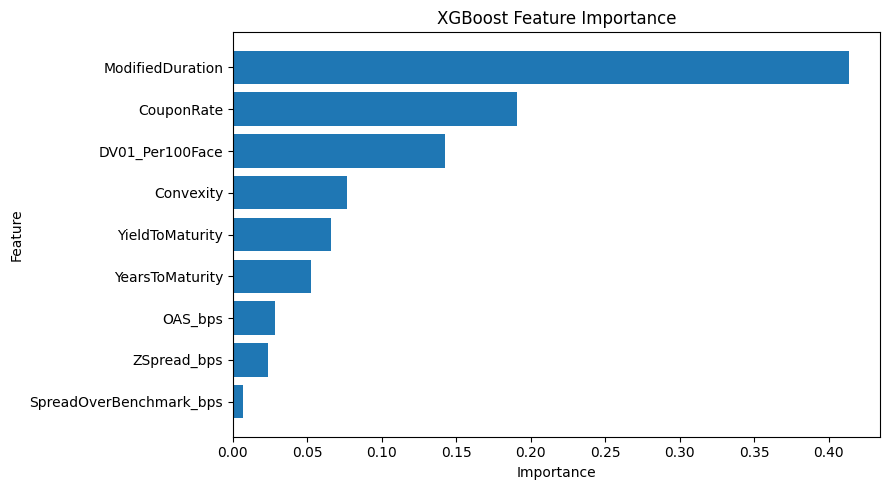

In [6]:
plt.figure(figsize=(9, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

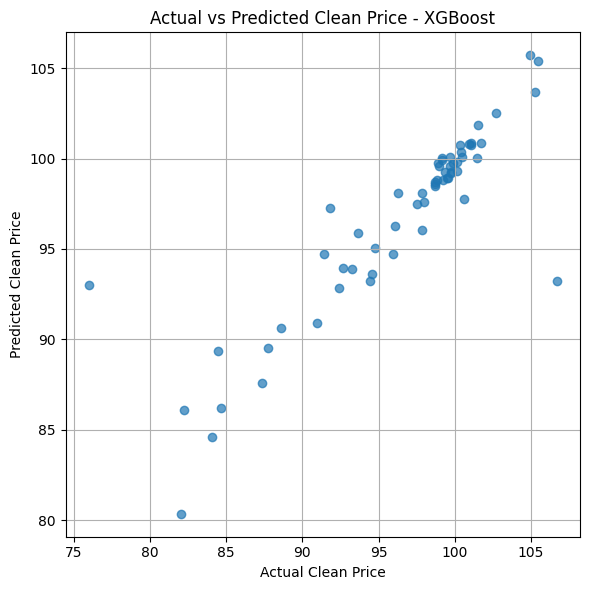

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.title("Actual vs Predicted Clean Price - XGBoost")
plt.xlabel("Actual Clean Price")
plt.ylabel("Predicted Clean Price")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
xgb_results.to_csv(REPORTS_DIR / "xgboost_results_day8.csv", index=False)
feature_importance.to_csv(REPORTS_DIR / "xgboost_feature_importance_day8.csv", index=False)

print("Day 8 XGBoost outputs saved successfully.")

Day 8 XGBoost outputs saved successfully.
